# 04 Clustering (DuckDB Input + BLOB Artifacts)

This notebook performs unsupervised clustering on session text, writes cluster assignments to DuckDB, and stores clustering artifacts as BLOBs.

In [1]:
from pathlib import Path
import json
import pickle

import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

from utils.duckdb_utils import init_ml_artifacts_table, open_duckdb, query_df
from utils.paths import get_db_paths, resolve_workspace
from utils.text_features import extract_cluster_terms
            


In [2]:
workspace = resolve_workspace(Path.cwd())
input_db, output_db = get_db_paths(workspace)

init_ml_artifacts_table(output_db)
            


In [3]:
df = query_df(
    input_db,
    '''
    SELECT
      file,
      title,
      COALESCE(NULLIF(text, ''), description) AS text,
      description,
      speakers,
      day,
      track
    FROM sessions_in_preprocessed
    WHERE COALESCE(NULLIF(text, ''), description) IS NOT NULL
    '''
)

def build_cluster_text(row):
    parts = [
        row.get('title') or '',
        row.get('text') or '',
        row.get('description') or '',
        str(row.get('speakers') or ''),
    ]
    return ' '.join(parts)

df['cluster_text'] = df.apply(build_cluster_text, axis=1)

vectorizer = TfidfVectorizer(max_features=6000, min_df=2, ngram_range=(1, 2), stop_words='english')
X = vectorizer.fit_transform(df['cluster_text'])

candidate_k = list(range(2, 9))
scores = []
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append((k, score))

best_k, best_score = max(scores, key=lambda x: x[1])
print(f'best_k={best_k}, silhouette={best_score:.4f}')
            


best_k=2, silhouette=0.0247


In [4]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

cluster_terms_df = extract_cluster_terms(vectorizer, X, labels, top_n=8)

cluster_df = pd.DataFrame({
    'file': df['file'],
    'title': df['title'],
    'day': df['day'],
    'track': df['track'],
    'cluster_id': labels,
    'pc1': coords[:, 0],
    'pc2': coords[:, 1]
})

cluster_df = cluster_df.merge(cluster_terms_df, on='cluster_id', how='left')

with open_duckdb(output_db, read_only=False) as write_con:
    write_con.register('cluster_df', cluster_df)
    write_con.execute('CREATE OR REPLACE TABLE clustering_assignments AS SELECT * FROM cluster_df')

    write_con.register('cluster_terms_df', cluster_terms_df)
    write_con.execute('CREATE OR REPLACE TABLE clustering_keywords AS SELECT * FROM cluster_terms_df')

    metrics = {
        'best_k': int(best_k),
        'silhouette': float(best_score),
        'candidate_scores': [{'k': int(k), 'silhouette': float(s)} for k, s in scores],
        'cluster_keywords': cluster_terms_df.to_dict(orient='records')
    }
    artifact_blob = pickle.dumps({'vectorizer': vectorizer, 'kmeans': kmeans, 'pca': pca})

    write_con.execute('''
    INSERT OR REPLACE INTO ml_artifacts
    (artifact_id, notebook, artifact_type, model_name, metrics_json, artifact_blob)
    VALUES (?, ?, ?, ?, ?, ?)
    ''', [
        'clustering_kmeans_text',
        '04_clustering',
        'clustering_model',
        'KMeans + TFIDF + PCA',
        json.dumps(metrics),
        artifact_blob
    ])

cluster_df.head()
            


,file,title,day,track,cluster_id,pc1,pc2
0,"90 Days, 1 Fabric Foundation- Delivering SQL M...","90 Days, 1 Fabric Foundation: Delivering SQL M...",Friday,Data Integration,0,-0.033761,0.027494
1,A data lake built for scale - deep dive into O...,A data lake built for scale: a deep dive into ...,Friday,OneLake,0,-0.086198,-0.010677
2,A Guide to Making the Most of your SQL Skills ...,A Guide to Making the Most of your SQL Skills ...,Thursday,SQL in Fabric,0,-0.058231,0.106044
3,Accelerate Data Transformation with Dataflows ...,Accelerate Data Transformation with Dataflows ...,Thursday,Data Integration,1,0.223537,-0.226968
4,Accelerate Your Move to Microsoft Fabric- Key ...,Accelerate Your Move to Microsoft Fabric: Key ...,Wednesday,Admin and Governance,0,-0.033085,-0.046922


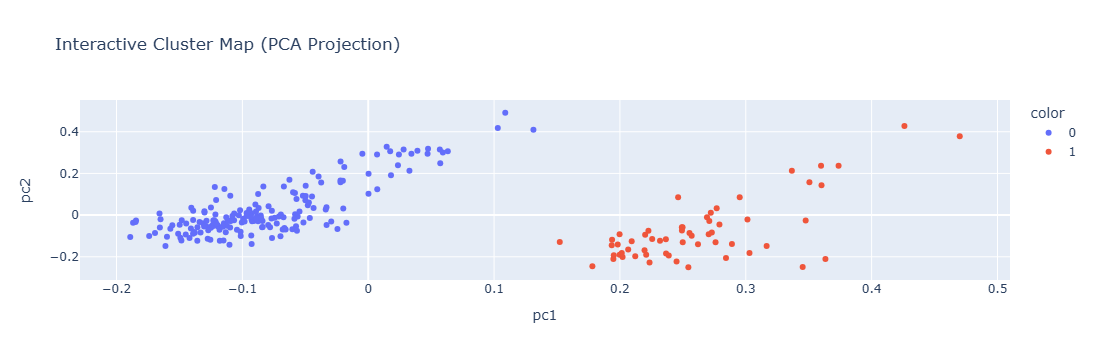

In [5]:
fig = px.scatter(
    cluster_df,
    x='pc1',
    y='pc2',
    color=cluster_df['cluster_id'].astype(str),
    hover_name='title',
    hover_data=['day', 'track', 'top_terms'],
    title='Interactive Cluster Map (PCA Projection + Key Terms)'
)
fig.show()
            
